# Supervised Fine-Tuning

## 14. Environment and Paths

This section checks the runtime environment, mounts Google Drive, and defines the paths for:
- the saved M05 checkpoint
- the JSON instruction dataset

In [ ]:
from importlib.metadata import version

pkgs = [
    "numpy",       # PyTorch & TensorFlow dependency
    "matplotlib",  # Plotting library
    "tiktoken",    # Tokenizer
    "torch",       # Deep learning library
    "tqdm",        # Progress bar
    "tensorflow",  # For OpenAI's pretrained weights
]
for p in pkgs:
    print(f"{p} version: {version(p)}")
    # check the versions, you may get error in windows

numpy version: 2.0.2
matplotlib version: 3.10.0
tiktoken version: 0.12.0
torch version: 2.10.0+cu128
tqdm version: 4.67.3
tensorflow version: 2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model_path = "/content/drive/MyDrive/SDAIA/model.pth"

## 15. Loading the Instruction Dataset

This section loads the JSON dataset used for supervised fine-tuning.

### Dataset format
Each entry follows:
- `instruction`
- `input`
- `output`

This matches the project’s instruction fine-tuning requirement.

#### Adding my own JSON

In [ ]:
import json

file_path = "/content/drive/MyDrive/SDAIA/m07_instruction_data_240.json"

with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)

print("Number of entries:", len(data))
print("Example entry:\n", data[0])

Number of entries: 240
Example entry:
 {'instruction': 'Summarize the following story in one sentence.', 'input': 'Lily finds a needle and asks her mother to help sew a button on her shirt.', 'output': 'Lily finds a needle and asks her mother to help sew a button on her shirt.'}


In [ ]:
data

[{'instruction': 'Summarize the following story in one sentence.',
  'input': 'Lily finds a needle and asks her mother to help sew a button on her shirt.',
  'output': 'Lily finds a needle and asks her mother to help sew a button on her shirt.'},
 {'instruction': 'Give a short title for the following story.',
  'input': 'Lily finds a needle and asks her mother to help sew a button on her shirt.',
  'output': 'Lily Shares the Needle'},
 {'instruction': 'Who is the main character in this story?',
  'input': 'Lily finds a needle and asks her mother to help sew a button on her shirt.',
  'output': 'The main character is Lily.'},
 {'instruction': 'Where does this story mainly take place?',
  'input': 'Lily finds a needle and asks her mother to help sew a button on her shirt.',
  'output': 'This story mainly takes place at home with her mother.'},
 {'instruction': 'What problem appears in this story?',
  'input': 'Lily finds a needle and asks her mother to help sew a button on her shirt.',
 

## 16. Instruction Prompt Formatting

This section defines the prompt template used for fine-tuning.

The format is:

- Instruction
- Optional Input
- Response

This helps the model learn instruction-following behavior.

In [ ]:
#keep
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [ ]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is the moral of this story?

### Input:
Lily and her animal friends work together to clear a cobweb so they can play again.

### Response:
Working together helps solve scary problems.


In [ ]:
model_input = format_input(data[200])
desired_response = f"\n\n### Response:\n{data[200]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Who is the main character in this story?

### Input:
Tom changes a hoop until it is the right size and then happily plays with it.

### Response:
The main character is Tom.


## 17. Train / Validation / Test Split

This section splits the instruction dataset into:
- training set
- validation set
- test set

### Split used
- 85% training
- 10% test
- 5% validation

In [ ]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [ ]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 204
Validation set length: 12
Test set length: 24


## 18. Instruction Dataset Class

This section tokenizes the formatted instruction-response samples and prepares them for supervised fine-tuning.

In [ ]:
import torch
from torch.utils.data import Dataset


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
            tokenizer.encode(full_text, allowed_special={"<|endoftext|>"})
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

## 19. Tokenizer for Fine-Tuning

This section initializes the GPT-2 tokenizer and verifies the special end-of-text token.

In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [ ]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )

        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [ ]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [ ]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [ ]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


## 20. Collation, Padding, and Label Masking

This section:
- pads variable-length instruction samples
- builds input and target tensors
- masks ignored positions using `-100`

This is required for stable supervised fine-tuning.

In [ ]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [ ]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [ ]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [ ]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [ ]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cuda


In [ ]:
print(f"Torch Version: {torch.__version__}")

Torch Version: 2.10.0+cu128


## 21. Fine-Tuning Dataloaders

This section creates train, validation, and test dataloaders for the instruction dataset.

### Important
The maximum allowed sequence length is matched to the same context length used in the phase 1 model.

In [ ]:
from functools import partial
MODEL_CONTEXT_LENGTH = 256
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length = MODEL_CONTEXT_LENGTH
)

In [ ]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [ ]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [ ]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 90]) torch.Size([8, 90])
torch.Size([8, 89]) torch.Size([8, 89])
torch.Size([8, 90]) torch.Size([8, 90])
torch.Size([8, 87]) torch.Size([8, 87])
torch.Size([8, 90]) torch.Size([8, 90])
torch.Size([8, 92]) torch.Size([8, 92])
torch.Size([8, 93]) torch.Size([8, 93])
torch.Size([8, 88]) torch.Size([8, 88])
torch.Size([8, 88]) torch.Size([8, 88])
torch.Size([8, 91]) torch.Size([8, 91])
torch.Size([8, 86]) torch.Size([8, 86])
torch.Size([8, 90]) torch.Size([8, 90])
torch.Size([8, 90]) torch.Size([8, 90])
torch.Size([8, 92]) torch.Size([8, 92])
torch.Size([8, 91]) torch.Size([8, 91])
torch.Size([8, 84]) torch.Size([8, 84])
torch.Size([8, 94]) torch.Size([8, 94])
torch.Size([8, 94]) torch.Size([8, 94])
torch.Size([8, 92]) torch.Size([8, 92])
torch.Size([8, 92]) torch.Size([8, 92])
torch.Size([8, 86]) torch.Size([8, 86])
torch.Size([8, 90]) torch.Size([8, 90])
torch.Size([8, 95]) torch.Size([8, 95])
torch.Size([8, 87]) torch.Size([8, 87])
torch.Size([8, 87]) torch.

In [ ]:
print(inputs[0])

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198, 33706,   262,  1808,   546,   262,  1621,
           13,   198,   198, 21017, 23412,    25,   198, 11605, 10638,    25,
        20037,   290,   607,  5044,  2460,   670,  1978,   284,  1598,   257,
        22843, 12384,   523,   484,   460,   711,   757,    13,   198, 24361,
           25,  5338,  4193, 20037,   351,   262, 22843, 12384,    30,   198,
          198, 21017, 18261,    25,   198,   464,  3797,   290,   262,  3290,
         4193, 20037,  3424,   262, 22843, 12384,    13], device='cuda:0')


- Similarly, we visually double-check that the targets contain the -100 placeholder tokens

In [ ]:
print(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198, 33706,   262,  1808,   546,   262,  1621,    13,
          198,   198, 21017, 23412,    25,   198, 11605, 10638,    25, 20037,
          290,   607,  5044,  2460,   670,  1978,   284,  1598,   257, 22843,
        12384,   523,   484,   460,   711,   757,    13,   198, 24361,    25,
         5338,  4193, 20037,   351,   262, 22843, 12384,    30,   198,   198,
        21017, 18261,    25,   198,   464,  3797,   290,   262,  3290,  4193,
        20037,  3424,   262, 22843, 12384,    13, 50256], device='cuda:0')


## 22. Loading the Pretrained M05 Checkpoint

This section rebuilds the same GPT architecture used in M05 and loads the saved checkpoint before fine-tuning.

### Important
The model must use the exact same architecture as the saved M05 model:
- vocab size
- context length
- embedding dimension
- number of heads
- number of layers
- qkv bias setting

In [ ]:
import torch
from previous_chapters import GPTModel

# IMPORTANT:
# This config must match your saved M05 model EXACTLY.
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 256,
    "n_heads": 8,
    "n_layers": 6,
    "drop_rate": 0.7,
    "qkv_bias": False
}

model = GPTModel(GPT_CONFIG_124M)
state_dict = torch.load(model_path, map_location="cpu")
model.load_state_dict(state_dict)

print("M05 checkpoint loaded successfully.")

M05 checkpoint loaded successfully.


In [ ]:
MODEL_CONTEXT_LENGTH = GPT_CONFIG_124M["context_length"]

## 23. Base Model Behavior Before Fine-Tuning

This section generates a response from the pretrained checkpoint before supervised fine-tuning, so it can be compared later with the fine-tuned model.

In [ ]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
State the ending mood of the story in a short phrase.

### Input:
Max hurts his knee, gets advice from an owl, and feels better after walking slowly.


In [ ]:
from previous_chapters import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer).to(device),
    max_new_tokens=60,
    context_size=MODEL_CONTEXT_LENGTH,
    eos_id=50256,
)

generated_text = token_ids_to_text(token_ids, tokenizer)
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
State the ending mood of the story in a short phrase.

### Input:
Max hurts his knee, gets advice from an owl, and feels better after walking slowly. He is so excited to see the rabbit. He is so he was scared and he could not see the best friend. He was too.

The bear was so happy that he was so happy to have a big adventure. He has a new friend. He was happy and the best friend.


- Note that the `generate` function we used in previous chapters returns the combined input and output text, which was convenient in the previous section for creating legible text
- To isolate the response, we can subtract the length of the instruction from the start of the `generated_text`

In [ ]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)
print(response_text)

He was so happy to play with his friends. He was so happy that he had a good day. He was so proud of himself that he had been so much fun!


In [ ]:
from previous_chapters import (
    calc_loss_loader,
    train_model_simple
)


## 24. Baseline Loss Before Fine-Tuning

This section measures training and validation loss before instruction fine-tuning begins.

In [ ]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 6.9264298439025875
Validation loss: 7.004377365112305


## 25. Supervised Fine-Tuning

This section fine-tunes the pretrained checkpoint on the instruction dataset.

### Notes
- A smaller learning rate is used here than in M05
- This stage teaches the model to follow instructions rather than only predict the next token in raw text

In [ ]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=0.01
)

num_epochs = 30

train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context=format_input(val_data[0]),
    tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 5.926, Val loss 6.080
Ep 1 (Step 000005): Train loss 5.809, Val loss 6.031
Ep 1 (Step 000010): Train loss 5.901, Val loss 5.985
Ep 1 (Step 000015): Train loss 5.837, Val loss 5.943
Ep 1 (Step 000020): Train loss 5.831, Val loss 5.906
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: State the ending mood of the story in a short phrase.  ### Input: Max hurts his knee, gets advice from an owl, and feels better after walking slowly.   "Look at the bear.  "Look at the bear.   "Look at the bear.  "Look, I am a big, but I am a big, but I am a big, but I
Ep 2 (Step 000025): Train loss 5.737, Val loss 5.871
Ep 2 (Step 000030): Train loss 5.654, Val loss 5.838
Ep 2 (Step 000035): Train loss 5.724, Val loss 5.807
Ep 2 (Step 000040): Train loss 5.662, Val loss 5.776
Ep 2 (Step 000045): Train loss 5.588, Val loss 5.745
Below is an instruction that describes a task. Write a response that appropr

## 26. Fine-Tuning Loss Curves

This section plots the training and validation losses for the fine-tuning stage.

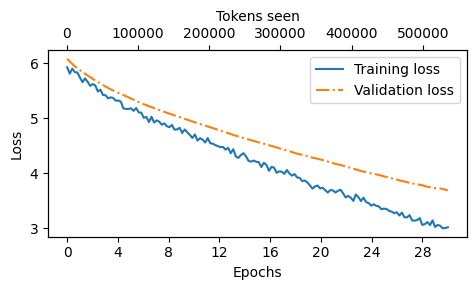

In [ ]:
from previous_chapters import plot_losses
# Alternatively:
# from llms_from_scratch.ch05 import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 27. Post-Fine-Tuning Evaluation Examples

This section compares generated responses on held-out test prompts against the expected outputs.

In [ ]:
torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=MODEL_CONTEXT_LENGTH,
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is the moral of this story?

### Input:
Tom changes a hoop until it is the right size and then happily plays with it.

Correct response:
>> Thinking hard can help solve a small problem.

Model response:
>> Tim and Tim and Timmy went to the story.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Answer the question about the story.

### Input:
Story summary: Tom changes a hoop until it is the right size and then happily plays with it.
Question: Why was the hoop a problem at first?

Correct response:
>> It was a problem because it was too big for Tom to play with.

Model response:
>> The moral of the story is:

Tim and the story is:

The moral of the story is the story is:

Tim and then on the story:
The moral of this story is that being kind to help

## 28. Saving Generated Test Responses

This section saves the model responses for the test set into a JSON file for later evaluation and error analysis.

In [ ]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=MODEL_CONTEXT_LENGTH,
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

100%|██████████| 24/24 [00:06<00:00,  3.51it/s]


In [ ]:
print(test_data[0])

{'instruction': 'What is the moral of this story?', 'input': 'Tom changes a hoop until it is the right size and then happily plays with it.', 'output': 'Thinking hard can help solve a small problem.', 'model_response': 'The moral of the story is the story is an important to be kind and have fun.\n\nThe moral of the story is the story story is the story is the story.\n\nThe moral of the story is:\n\nThe moral of the story:\n\nThe moral of the story is::\nTimmy is that day.\nTimmy and the story is:\n\nTimmy is:\n\nTimmy is a story. He takes a good day.\n\nTimmy.'}


## 29. Saving the Final Fine-Tuned Model

The final instruction-tuned model checkpoint is saved here.

In [ ]:
torch.save(model.state_dict(), "m07_finetuned_from_m05.pth")
print("Model saved as m07_finetuned_from_m05.pth")

Model saved as m07_finetuned_from_m05.pth


## 30. Optional Ollama-Based Evaluation

This section installs and runs Ollama for optional LLM-as-a-judge evaluation.

### Note
This section is optional and is not required for the core M05 → M07 training pipeline.

####Self-Reminder: Do this only once

In [ ]:
!apt-get update -qq
!apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh
!ollama serve > /tmp/ollama.log 2>&1 &

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 109 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (565 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Cleaning up old version at /usr/local/lib/ollama
>>> In

In [ ]:
!sleep 5
!ollama -v
!cat /tmp/ollama.log | tail -n 20

ollama version is 0.17.7
Couldn't find '/root/.ollama/id_ed25519'. Generating new private key.
Your new public key is: 

ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAIPH0TOVdd9ELCQLtJ5l/npCve6F6tE/LNhSh/FO9HyhT

time=2026-03-12T00:43:58.875Z level=INFO source=routes.go:1658 msg="server config" env="map[CUDA_VISIBLE_DEVICES: GGML_VK_VISIBLE_DEVICES: GPU_DEVICE_ORDINAL: HIP_VISIBLE_DEVICES: HSA_OVERRIDE_GFX_VERSION: HTTPS_PROXY: HTTP_PROXY: NO_PROXY: OLLAMA_CONTEXT_LENGTH:0 OLLAMA_DEBUG:INFO OLLAMA_EDITOR: OLLAMA_FLASH_ATTENTION:false OLLAMA_GPU_OVERHEAD:0 OLLAMA_HOST:http://127.0.0.1:11434 OLLAMA_KEEP_ALIVE:5m0s OLLAMA_KV_CACHE_TYPE: OLLAMA_LLM_LIBRARY: OLLAMA_LOAD_TIMEOUT:5m0s OLLAMA_MAX_LOADED_MODELS:0 OLLAMA_MAX_QUEUE:512 OLLAMA_MODELS:/root/.ollama/models OLLAMA_MULTIUSER_CACHE:false OLLAMA_NEW_ENGINE:false OLLAMA_NOHISTORY:false OLLAMA_NOPRUNE:false OLLAMA_NO_CLOUD:false OLLAMA_NUM_PARALLEL:1 OLLAMA_ORIGINS:[http://localhost https://localhost http://localhost:* https://localhost:* http://12

#####To Run ollama again

In [ ]:
!pkill -f "ollama serve" || true
!nohup ollama serve >/tmp/ollama.log 2>&1 &
!sleep 5
!cat /tmp/ollama.log | tail -n 30

^C
time=2026-03-12T00:55:59.726Z level=INFO source=routes.go:1658 msg="server config" env="map[CUDA_VISIBLE_DEVICES: GGML_VK_VISIBLE_DEVICES: GPU_DEVICE_ORDINAL: HIP_VISIBLE_DEVICES: HSA_OVERRIDE_GFX_VERSION: HTTPS_PROXY: HTTP_PROXY: NO_PROXY: OLLAMA_CONTEXT_LENGTH:0 OLLAMA_DEBUG:INFO OLLAMA_EDITOR: OLLAMA_FLASH_ATTENTION:false OLLAMA_GPU_OVERHEAD:0 OLLAMA_HOST:http://127.0.0.1:11434 OLLAMA_KEEP_ALIVE:5m0s OLLAMA_KV_CACHE_TYPE: OLLAMA_LLM_LIBRARY: OLLAMA_LOAD_TIMEOUT:5m0s OLLAMA_MAX_LOADED_MODELS:0 OLLAMA_MAX_QUEUE:512 OLLAMA_MODELS:/root/.ollama/models OLLAMA_MULTIUSER_CACHE:false OLLAMA_NEW_ENGINE:false OLLAMA_NOHISTORY:false OLLAMA_NOPRUNE:false OLLAMA_NO_CLOUD:false OLLAMA_NUM_PARALLEL:1 OLLAMA_ORIGINS:[http://localhost https://localhost http://localhost:* https://localhost:* http://127.0.0.1 https://127.0.0.1 http://127.0.0.1:* https://127.0.0.1:* http://0.0.0.0 https://0.0.0.0 http://0.0.0.0:* https://0.0.0.0:* app://* file://* tauri://* vscode-webview://* vscode-file://*] OLLAMA

In [ ]:
# !ollama pull gemma3

Error: could not connect to ollama server, run 'ollama serve' to start it


In [ ]:
import json
import urllib.request

url = "http://127.0.0.1:11434/api/chat"
payload = {
    "model": "llama3",
    "messages": [
        {"role": "user", "content": "Say hello in one short sentence."}
    ],
    "stream": False
}

req = urllib.request.Request(
    url,
    data=json.dumps(payload).encode("utf-8"),
    headers={"Content-Type": "application/json"},
    method="POST"
)

with urllib.request.urlopen(req) as response:
    result = json.loads(response.read().decode("utf-8"))

print(result["message"]["content"])

Hello!


In [ ]:
!ollama pull llama3

In [ ]:
# # 8B model
# !ollama run llama3

Error: could not connect to ollama server, run 'ollama serve' to start it


In [ ]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


In [ ]:
# This cell is optional; it allows you to restart the notebook
# and only run section 7.7 without rerunning any of the previous code
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [ ]:
import subprocess
import time

# Start Ollama in the background
subprocess.Popen(["ollama", "serve"])

# Give it a few seconds to initialize
time.sleep(5)

print("Ollama started in the background.")

Ollama started in the background.


In [ ]:
import requests  # noqa: F811
# import urllib.request

def query_model(
    prompt,
    model="llama3",
    # If you used OLLAMA_HOST=127.0.0.1:11435 ollama serve
    # update the address from 11434 to 11435
    url="http://localhost:11434/api/chat"
):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # Settings below are required for deterministic responses
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }


    """
    # Convert the dictionary to a JSON formatted string and encode it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Create a request object, setting the method to POST and adding necessary headers
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")

    # Send the request and capture the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # Read and decode the response
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data
    """

    # The book originally used the commented-out above, which is based
    # on urllib. It works generally fine, but some readers reported
    # issues with using urlib when using a (company) VPN.
    # The code below uses the requests library, which doesn't seem
    # to have these issues.

    # Send the POST request
    with requests.post(url, json=data, stream=True, timeout=30) as r:
        r.raise_for_status()
        response_data = ""
        for line in r.iter_lines(decode_unicode=True):
            if not line:
                continue
            response_json = json.loads(line)
            if "message" in response_json:
                response_data += response_json["message"]["content"]

    return response_data


model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily eat plants and plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: Hay is a staple in a llama's diet. They enjoy a variety of hay types, such as timothy hay, alfalfa hay, and oat hay.
3. Grains: Llamas may be fed grains like oats, barley, and corn as a supplement to their diet.
4. Fruits and vegetables: Llamas enjoy fruits and vegetables as treats or as a way to add variety to their diet. Some examples include apples, carrots, and sweet potatoes.
5. Leaves: Llamas will also eat leaves from trees and shrubs, such as willow, alder, and birch.
6. Bark: In the winter or when other food sources are scarce, llamas may eat the bark of trees, such as willow or aspen.

In the wild, llamas will roam freely and eat whatever is available in their natural habitat. In captivity, their diet is typically formulated to meet thei

In [ ]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> Thinking hard can help solve a small problem.

Model response:
>> The moral of the story is the story is an important to be kind and have fun.

The moral of the story is the story story is the story is the story.

The moral of the story is:

The moral of the story:

The moral of the story is::
Timmy is that day.
Timmy and the story is:

Timmy is:

Timmy is a story. He takes a good day.

Timmy.

Score:
>> I'd score the model response a 20 out of 100. The response is not relevant to the input and does not accurately capture the moral of the story. The input describes Tom changing a hoop to the right size and then playing with it happily, which suggests that the moral of the story is about perseverance and finding joy in solving a small problem. The model response does not address this theme at all.

-------------------------

Dataset response:
>> It was a problem because it was too big for Tom to play with.

Model response:
>> Tim and his friends play together in th

In [ ]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|██████████| 24/24 [00:09<00:00,  2.46it/s]

Number of scores: 24 of 24
Average score: 21.00



## 31. Error Analysis and Limitations

### Observed issues
- some prompts may produce repetitive or incomplete responses
- the model performs better on simple instruction styles than complex ones
- fine-tuning quality depends strongly on dataset coverage and consistency

### Limitations
- the model is trained on a relatively small custom setup
- context length is limited
- performance is not comparable to large production LLMs
- output quality depends on both base pretraining and SFT dataset quality

# Instant Testing

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print("Tokenizer loaded.")

Tokenizer loaded.


## 33. Instant Test — M07 Fine-Tuned Model

This section runs a quick instruction-following test using the fine-tuned M07 checkpoint.

**Purpose**
- Verify that the M07 checkpoint loads correctly
- Check instruction-following behavior
- Compare against the M05 base model

In [3]:
def format_input(entry):
    instruction_text = (
        "Below is an instruction that describes a task. "
        "Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text

In [5]:
# ===== Instant Test: Fine-Tuned Model (3 Examples) =====

import torch
import tiktoken
from previous_chapters import GPTModel, generate_text_simple

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = tiktoken.get_encoding("gpt2")

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())

def generate(model, idx, max_new_tokens, context_size, eos_id=None):
    return generate_text_simple(
        model=model,
        idx=idx,
        max_new_tokens=max_new_tokens,
        context_size=context_size
    )

def format_input(entry):
    instruction_text = (
        "Below is an instruction that describes a task. "
        "Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text

# Must match the same architecture used in M05/M07
GPT_CONFIG_M07 = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 256,
    "n_heads": 8,
    "n_layers": 6,
    "drop_rate": 0.7,
    "qkv_bias": False
}

# Change this path if needed
m07_model_path = "/content/drive/MyDrive/SDAIA/m07_finetuned_from_m05.pth"

m07_model = GPTModel(GPT_CONFIG_M07)
m07_state_dict = torch.load(m07_model_path, map_location="cpu")
m07_model.load_state_dict(m07_state_dict)
m07_model.to(device)
m07_model.eval()

test_entries = [
    {
        "instruction": "Who is the main character in this story?",
        "input": "One day, a little girl named Lily found a needle in her room. She asked her mother to help sew a button on her shirt. Together, they shared the needle, fixed the shirt, and felt happy because they worked together."
    },
    {
        "instruction": "How is the problem solved in this story?",
        "input": "Tim takes Sam for a ride in a loud car, and then they play together at the park."
    },
    {
        "instruction": "What is the moral of this story?",
        "input": "A little fish named Fin saw a crab that felt cold and did not want to play. Fin asked the sun to shine on the shore so the crab could feel warm again. After that, the crab felt better, thanked Fin, and they became friends."
    }
]

for i, test_entry in enumerate(test_entries, start=1):
    m07_prompt = format_input(test_entry)

    with torch.no_grad():
        m07_token_ids = generate(
            model=m07_model,
            idx=text_to_token_ids(m07_prompt, tokenizer).to(device),
            max_new_tokens=80,
            context_size=GPT_CONFIG_M07["context_length"],
            eos_id=50256
        )

    m07_generated_text = token_ids_to_text(m07_token_ids, tokenizer)
    m07_response = m07_generated_text[len(m07_prompt):].replace("### Response:", "").strip()

    print(f"===== M07 FINE-TUNED MODEL TEST {i} =====")
    print("Instruction Prompt:")
    print(m07_prompt)
    print("\nGenerated Response:")
    print(m07_response)
    print("\n" + "=" * 70 + "\n")

===== M07 FINE-TUNED MODEL TEST 1 =====
Instruction Prompt:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Who is the main character in this story?

### Input:
One day, a little girl named Lily found a needle in her room. She asked her mother to help sew a button on her shirt. Together, they shared the needle, fixed the shirt, and felt happy because they worked together.

Generated Response:
Lily and they could play together.<|endoftext|>

Lily and her friends.<|endoftext|>

Lily and her friends. She loved to play together. She had a fun day long time. One day, Lily's mommy went to play with her friends.



Lily's mommy and daddy. They saw a big tree with a big tree. Lily


===== M07 FINE-TUNED MODEL TEST 2 =====
Instruction Prompt:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
How is the problem solved in this story?

### Input:
Tim